In [1]:
import os
import kagglehub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("briscdataset/brisc2025")

In [2]:

data_path = os.path.join(path)

In [6]:
train_dir = os.path.join(
    data_path,
    "brisc2025",
    "classification_task",
    "train"
)

print(train_dir)
print(os.path.exists(train_dir))
print(os.listdir(train_dir))

C:\Users\RAHUL MANGUTKAR\.cache\kagglehub\datasets\briscdataset\brisc2025\versions\6\brisc2025\classification_task\train
True
['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [3]:
os.listdir(data_path)

['brisc2025']

In [4]:
print(type(os.listdir(data_path)))

<class 'list'>


In [7]:

def analyze_class_type(classname: str) -> dict:
  image_size = set()
  image_mode = set()
  image_format = set()
  overall_min_pixel = float('inf') 
  overall_max_pixel = float('-inf') 
  class_dir = os.path.join(data_path, "brisc2025","classification_task","train",classname)
  image_files = os.listdir(class_dir)
  file_size = len(image_files)
  for img_filename in image_files:
    img_path = os.path.join(class_dir, img_filename)
    images = Image.open(img_path)
    image_size.add(images.size)
    image_mode.add(images.mode)
    image_format.add(images.format)
    images_array = np.array(images)
    overall_min_pixel = min(overall_min_pixel, images_array.min())
    overall_max_pixel = max(overall_max_pixel, images_array.max())

  return {
    "total_images": file_size,
    "image_size": image_size,
    "image_mode": image_mode,
    "image_format": image_format,
    "min_pixel": overall_min_pixel,
    "max_pixel": overall_max_pixel
}

In [8]:
for cls in os.listdir( os.path.join(data_path, "brisc2025","classification_task","train")):
  print(f"******** class Analyse Report for {cls}********")
  for key, values in analyze_class_type(cls).items():
    print(f"{key}: {values}")
  print("-"*100)

******** class Analyse Report for glioma********
total_images: 1147
image_size: {(512, 512)}
image_mode: {'RGB', 'L'}
image_format: {'JPEG'}
min_pixel: 0
max_pixel: 255
----------------------------------------------------------------------------------------------------
******** class Analyse Report for meningioma********
total_images: 1329
image_size: {(257, 320), (209, 225), (491, 624), (278, 306), (411, 396), (552, 527), (338, 345), (503, 369), (200, 252), (201, 251), (318, 354), (485, 510), (230, 241), (420, 264), (306, 306), (289, 354), (528, 581), (204, 249), (554, 554), (330, 355), (264, 336), (374, 370), (530, 526), (214, 216), (1275, 1427), (201, 207), (229, 223), (212, 237), (213, 236), (645, 439), (323, 342), (216, 216), (305, 337), (209, 241), (351, 398), (300, 359), (630, 423), (306, 365), (455, 500), (291, 340), (298, 354), (374, 456), (472, 546), (329, 314), (315, 315), (256, 256), (300, 345), (312, 401), (369, 398), (295, 394), (239, 224), (250, 270), (313, 393), (225, 2

In [9]:
train_data_path = os.path.join(data_path, "brisc2025","classification_task","train")
test_data_path = os.path.join(data_path, "brisc2025","classification_task","test")

In [10]:
def get_all_image_paths(folder_path):
    image_paths = []

    for cls in os.listdir(folder_path):
        class_path = os.path.join(folder_path, cls)

        for file in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, file))

    return image_paths

In [11]:
def find_corrupted_images(folder_path:str) -> list:

    corrupted = []

    for file_path in get_all_image_paths(folder_path):

        try:
            img = Image.open(file_path)
            img.verify()

        except Exception:
            corrupted.append(file_path)

    return corrupted

In [12]:
find_corrupted_images(train_data_path)

[]

In [13]:
from typing import Tuple

def find_empty_images(folder_path: str) -> Tuple[list, int]:
    empty_images = []

    for file_path in get_all_image_paths(folder_path):

        if os.path.getsize(file_path) == 0:
            empty_images.append(file_path)

    return empty_images, len(empty_images)

In [14]:
empty_images, count = find_empty_images(train_data_path)

if count == 0:
    print("No empty image files found in the dataset.")
elif count >= 5:
    print(f"Found {count} empty image(s):")
    for img in empty_images:
        print(img)

No empty image files found in the dataset.


In [15]:
def analyze_intensity_distribution(folder_path:str, *args:str)-> dict:
  mean_value = {}
  class_path = os.path.join(folder_path,*args)
  for file in os.listdir(class_path):
    file_path = os.path.join(class_path, file)
    with Image.open(file_path) as image:
      image_array = np.array(image)
    mean_value[file] = image_array.mean()
  darkest_image = min(mean_value, key=mean_value.get)
  brightest_image = max(mean_value, key=mean_value.get)
  average = round(np.mean(list(mean_value.values())), 2)
  return {
    "Total Images": len(mean_value),
    "Average Mean Intensity": average ,
    "Darkest Image": darkest_image,
    "Darkest Image Mean": round(mean_value[darkest_image],2),
    "Brightest Image" : brightest_image,
    "Brightest Image Mean": round(mean_value[brightest_image],2)
}

In [16]:
for cls in os.listdir(train_data_path):
  print(f"******** Intensity Report for {cls} ********")
  for key, values in analyze_intensity_distribution(train_data_path,cls).items():
    
    print(f"{key}: {values}")
  print("-"*100)


******** Intensity Report for glioma ********
Total Images: 1147
Average Mean Intensity: 33.1
Darkest Image: brisc2025_train_00611_gl_co_t1.jpg
Darkest Image Mean: 13.69
Brightest Image: brisc2025_train_01055_gl_sa_t1.jpg
Brightest Image Mean: 68.36
----------------------------------------------------------------------------------------------------
******** Intensity Report for meningioma ********
Total Images: 1329
Average Mean Intensity: 43.17
Darkest Image: brisc2025_train_01508_me_ax_t1.jpg
Darkest Image Mean: 18.23
Brightest Image: brisc2025_train_01666_me_co_t1.jpg
Brightest Image Mean: 137.76
----------------------------------------------------------------------------------------------------
******** Intensity Report for no_tumor ********
Total Images: 1067
Average Mean Intensity: 50.57
Darkest Image: brisc2025_train_02885_no_co_t1.jpg
Darkest Image Mean: 17.27
Brightest Image: brisc2025_train_02755_no_ax_t1.jpg
Brightest Image Mean: 112.58
--------------------------------------

In [17]:
def visualize_darkest_images(image_path: str,):
  for cls in os.listdir(image_path):
    report = analyze_intensity_distribution(image_path, cls)
    darkest_file = report["Darkest Image"]
    darkest_path = os.path.join(image_path,cls,
    darkest_file )
    with Image.open(darkest_path) as img:
      plt.figure(figsize=(5,5))
      plt.axis("off")
      plt.title(f"The darkest image for class {cls}:")
      plt.imshow(img)
      plt.show()
    


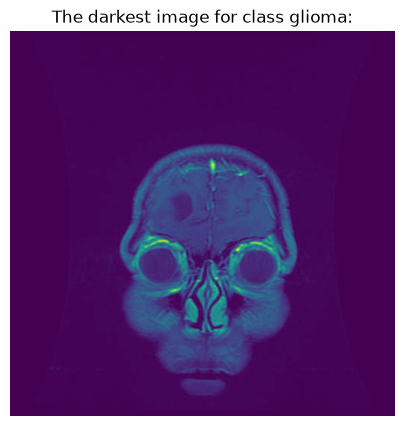

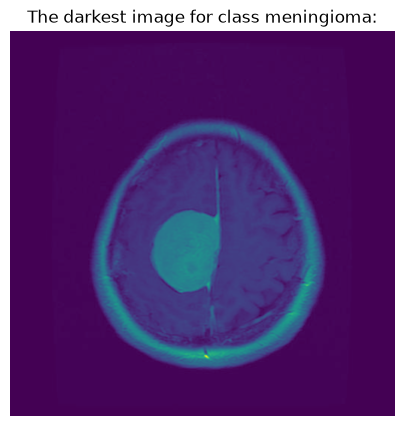

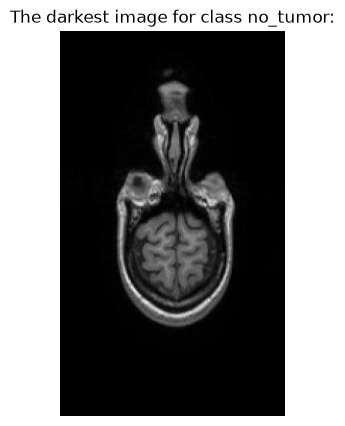

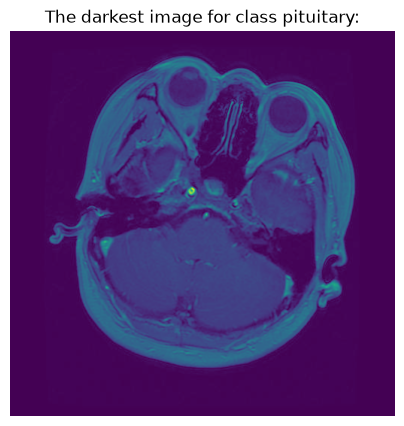

In [18]:
visualize_darkest_images(train_data_path)

In [19]:
def visualize_brightess_images(image_path: str,):
  for cls in os.listdir(image_path):
    report = analyze_intensity_distribution(image_path, cls)
    brightest_file = report["Brightest Image"]
    brightest_path = os.path.join(image_path,cls,
                      brightest_file )
    with Image.open(brightest_path) as img:
      plt.figure(figsize=(5,5))
      plt.axis("off")
      plt.title(f"The brightes image for class {cls}:")
      plt.imshow(img)
      plt.show()

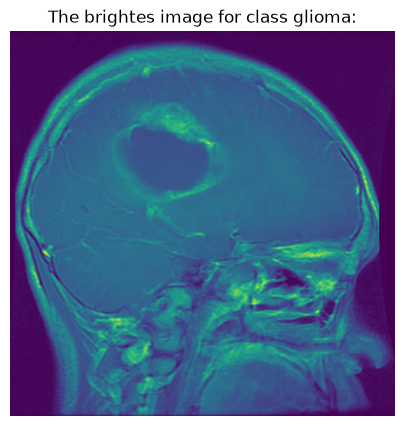

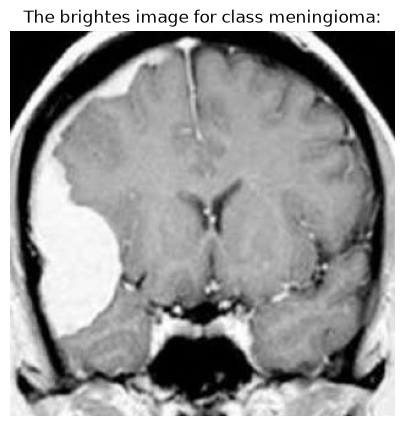

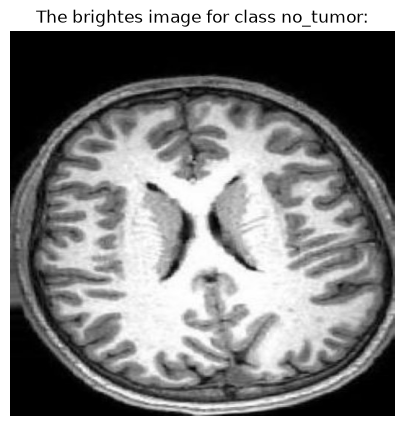

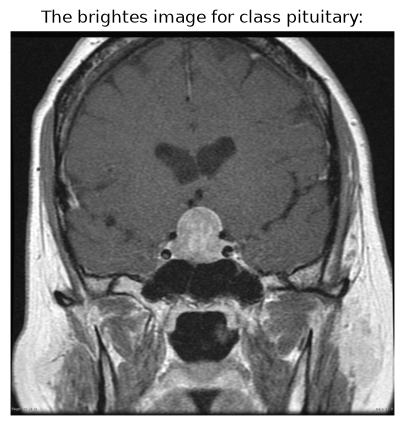

In [20]:
visualize_brightess_images(train_data_path)